# Part 3a: Steric height
Andrew Delman. Updated 2026-05-15.

## Objectives

To use ECCO state output to investigate steric height anomalies.

By the end of this tutorial, you will be able to:

* Compute steric height anomaly (SHA)
* Compare SHA with sea surface height
* Use the Jackett and McDougall (1995) equation of state to carry out conversions of temperature and salinity to specific volume/density
* Estimate contributions of temperature and salinity to SHA

## Introduction

### Steric height anomaly formulation

Though the density of ocean water changes relatively little compared to the density of air and other gases, even relatively small variations in ocean water density have large impacts on the ocean circulation and sea level variations. Under the conditions of hydrostatic balance (conditions assumed by the MITgcm model configuration run in ECCO v4r4), the vertical gradient of pressure $\partial{p}/\partial{z}$ is a function of density $\rho$ and gravitational acceleration $g$:

$$
\frac{\partial{p}}{\partial{z}} = -{\rho}g
$$

When the density of a parcel water changes, e.g. because its temperature or salinity changes, the parcel of water expands or contracts, and this has an effect on the vertical height of the parcel. This can be expressed in terms of the change in height between two pressure surfaces.

$$
{\Delta}z = \frac{{\Delta}p}{-{\rho}g}
$$

or in integral form

$$
h = \int_{p_r}^{p} \frac{dp}{-{\rho}g}
$$

which can also be notated in terms of the specific volume $V_{sp} \equiv 1/\rho$

$$
h = \int_{p_r}^{p} -\frac{V_{sp}}{g} \, dp
$$

(cf. Gill ch. 7.7, or discussion of thickness in Vallis ch. 2.6)

where $h$ is the steric height at pressure level $p$ relative to some reference pressure level $p_r$. The atmospheric analogue to steric height is called *thickness*, and is commonly used in meteorology and atmospheric science. Generally we are less interested in the value of the steric height itself than in its spatial or temporal variation, so the steric height anomaly $h^{\prime}$ can be defined in terms of a specific volume anomaly $V_{sp}^{\prime}$

$$
h^{\prime} = \int_{p_r}^{p} -\frac{V_{sp}^{\prime}}{g} \, dp
$$

where $V_{sp}^{\prime}$ is the anomaly from the a reference specific volume $V_r$. Sometimes the literature also refers to the geopotential anomaly, which is the steric height anomaly times $g$ (i.e., the above equation without dividing by $g$) and has units m$^2$ s$^{-2}$.



### Equation of state

Since we will be computing seawater density and its components associated with temperature and salinity changes, we need to use an [equation of state](https://en.wikipedia.org/wiki/TEOS-10) for seawater. Currently the international standard equation of state is [TEOS-10](https://www.teos-10.org/), which has the [GSW-Python package](https://teos-10.github.io/GSW-Python/) to facilitate computations in Python. However, ECCO's configuration of MITgcm uses an older version of the equation of state introduced by [Jackett and McDougall (1995)](https://doi.org/10.1175/1520-0426(1995)012%3C0381:MAOHPT%3E2.0.CO;2) to compute density variations. We will use this equation of state (abbreviated JMD95) here. Conveniently, there is a [Python implementation of JMD95](https://github.com/brian-rose/MITgcmutils/blob/master/MITgcmutils/jmd95.py) so that it is not necessary to code this ourselves. The *jmd95.py* module is included in the tutorial repository to facilitate its use here.

## Open files

For this tutorial, we will need the ECCO datasets with the following ShortNames:

- **ECCO_L4_GEOMETRY_LLC0090GRID_V4R4** (no time dimension)
- **ECCO_L4_DENS_STRAT_PRESS_LLC0090GRID_MONTHLY_V4R4** (Jan 2000)
- **ECCO_L4_SSH_LLC0090GRID_MONTHLY_V4R4** (Jan 2000)
- **ECCO_L4_TEMP_SALINITY_LLC0090GRID_MONTHLY_V4R4** (Jan 2000)

The notebook uses the `ecco_access` Python package to download these datasets. See [this tutorial](https://ecco-access.readthedocs.io/Using_ECCO_access.html) for more info on how to use `ecco_access`. If you are working on an AWS instance, just set `incloud_access = True` in the 1st cell and the datasets will be downloaded to your instance or opened remotely on S3 depending on your available storage.

In [1]:
# specify incloud_access = True if working in the AWS Cloud, otherwise False
incloud_access = False

from os.path import join,expanduser
user_home_dir = expanduser('~')

if incloud_access:
    access_mode = 's3_get_ifspace'
    download_root_dir = None
    # specify location to store json files that will speed up S3 data access
    jsons_root_dir = join(user_home_dir,'MZZ')  
else:
    access_mode = 'download_ifspace'
    # specify location to store downloaded files
    # ~/Downloads/ECCO_V4r4_PODAAC is also the default path used for download_root_dir; 
    # change as needed
    download_root_dir = join(user_home_dir,'Downloads','ECCO_V4r4_PODAAC')
    jsons_root_dir = None    


# import needed packages
import numpy as np
import xarray as xr
import glob
import sys
user_home_dir = expanduser('~')
import matplotlib.pyplot as plt

import ecco_v4_py as ecco
import ecco_access as ea
from ecco_po_tutorials import *

# import function that computes density in jmd95.py module
from jmd95 import densjmd95

In [2]:
# ShortNames
grid_params_shortname = "ECCO_L4_GEOMETRY_LLC0090GRID_V4R4"
denspress_monthly_shortname = "ECCO_L4_DENS_STRAT_PRESS_LLC0090GRID_MONTHLY_V4R4"
SSH_monthly_shortname = "ECCO_L4_SSH_LLC0090GRID_MONTHLY_V4R4"
TS_monthly_shortname = "ECCO_L4_TEMP_SALINITY_LLC0090GRID_MONTHLY_V4R4"

ShortNames_list = [grid_params_shortname,denspress_monthly_shortname,\
                   SSH_monthly_shortname,TS_monthly_shortname]

In [3]:
# specify location to store downloaded files

# ~/Downloads/ECCO_V4r4_PODAAC is also the default path used for download_root_dir; 
# change as needed
download_root_dir = join(user_home_dir,'Downloads','ECCO_V4r4_PODAAC')

### Grid and density/pressure files

If you've completed the previous tutorials you are quite familiar with these files by now.

In [4]:
# load grid parameters
ds_grid = ea.ecco_podaac_to_xrdataset(grid_params_shortname,\
                                      mode=access_mode,\
                                      download_root_dir=download_root_dir,\
                                      jsons_root_dir=jsons_root_dir,\
                                      prompt_request_payer=False)
ds_grid = ds_grid.compute()    # load into memory (rather than delaying computation)

# density/pressure dataset
ds_denspress = ea.ecco_podaac_to_xrdataset(denspress_monthly_shortname,\
                                      StartDate="2000-01",EndDate="2000-01",\
                                      mode=access_mode,\
                                      download_root_dir=download_root_dir,\
                                      jsons_root_dir=jsons_root_dir,\
                                      prompt_request_payer=False)
ds_denspress = ds_denspress.compute()

Download to directory /home/jpluser/Downloads/ECCO_V4r4_PODAAC/ECCO_L4_GEOMETRY_LLC0090GRID_V4R4
Size of files to be downloaded to instance is 0.008 GB,
which is 0.04% of the 18.521 GB available storage.
Proceeding with file downloads via NASA Earthdata URLs
DL Progress: 100%|###########################| 1/1 [00:02<00:00,  2.30s/it]

total downloaded: 8.57 Mb
avg download speed: 3.72 Mb/s
Time spent = 2.3052399158477783 seconds


Download to directory /home/jpluser/Downloads/ECCO_V4r4_PODAAC/ECCO_L4_DENS_STRAT_PRESS_LLC0090GRID_MONTHLY_V4R4
Size of files to be downloaded to instance is 0.029 GB,
which is 0.16% of the 18.513 GB available storage.
Proceeding with file downloads via NASA Earthdata URLs
DL Progress: 100%|###########################| 1/1 [00:03<00:00,  3.32s/it]

total downloaded: 30.98 Mb
avg download speed: 9.32 Mb/s
Time spent = 3.32550048828125 seconds




### Sea surface height file

To look at the impact of steric height variations, we will also be looking at the actual sea surface height field from ECCOv4. Consulting the [variable list](https://raw.githubusercontent.com/ECCO-GROUP/ECCO-v4-Python-Tutorial/master/varlist/v4r4_nctiles_monthly_varlist.txt) for monthly mean output, we find that the datasets containing sea surface height have ShortName ```ECCO_L4_SSH_LLC0090GRID_MONTHLY_V4R4```. To start, we access the granule of that dataset corresponding to January 2000 (2000-01).

In [5]:
ds_SSH = ea.ecco_podaac_to_xrdataset(SSH_monthly_shortname,\
                                      StartDate="2000-01",EndDate="2000-01",\
                                      mode=access_mode,\
                                      download_root_dir=download_root_dir,\
                                      jsons_root_dir=jsons_root_dir,\
                                      prompt_request_payer=False)
ds_SSH = ds_SSH.compute()

ds_SSH

Download to directory /home/jpluser/Downloads/ECCO_V4r4_PODAAC/ECCO_L4_SSH_LLC0090GRID_MONTHLY_V4R4
Size of files to be downloaded to instance is 0.006 GB,
which is 0.03% of the 18.484 GB available storage.
Proceeding with file downloads via NASA Earthdata URLs
DL Progress: 100%|###########################| 1/1 [00:02<00:00,  2.31s/it]

total downloaded: 5.92 Mb
avg download speed: 2.56 Mb/s
Time spent = 2.3119957447052 seconds




<xarray.Dataset> Size: 7MB
Dimensions:    (i: 90, i_g: 90, j: 90, j_g: 90, tile: 13, time: 1, nv: 2, nb: 4)
Coordinates: (12/13)
  * i          (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i_g        (i_g) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * j          (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * j_g        (j_g) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * tile       (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * time       (time) datetime64[ns] 8B 2000-01-16T12:00:00
    ...         ...
    YC         (tile, j, i) float32 421kB -88.24 -88.38 -88.52 ... -88.08 -88.1
    XG         (tile, j_g, i_g) float32 421kB -115.0 -115.0 ... -102.9 -109.0
    YG         (tile, j_g, i_g) float32 421kB -88.18 -88.32 ... -87.99 -88.02
    time_bnds  (time, nv) datetime64[ns] 16B 2000-01-01 2000-02-01
    XC_bnds    (tile, j, i, nb) float32 2MB -115.0 -115.0 ... -115.0 -108.5
    YC_bnds    (tile, j, i, nb) float32 2MB -88.18 -88.32 ... -88.18 -88.16
Dimensions without coordinates: nv, nb
Data variables:
    SSH        (time, tile, j, i) float32 421kB nan nan nan nan ... nan nan nan
    SSHIBC     (time, tile, j, i) float32 421kB nan nan nan nan ... nan nan nan
    SSHNOIBC   (time, tile, j, i) float32 421kB nan nan nan nan ... nan nan nan
    ETAN       (time, tile, j, i) float32 421kB nan nan nan nan ... nan nan nan
Attributes: (12/57)
    acknowledgement:              This research was carried out by the Jet Pr...
    author:                       Ian Fenty and Ou Wang
    cdm_data_type:                Grid
    comment:                      Fields provided on the curvilinear lat-lon-...
    Conventions:                  CF-1.8, ACDD-1.3
    coordinates_comment:          Note: the global 'coordinates' attribute de...
    ...                           ...
    time_coverage_duration:       P1M
    time_coverage_end:            2000-02-01T00:00:00
    time_coverage_resolution:     P1M
    time_coverage_start:          2000-01-01T00:00:00
    title:                        ECCO Sea Surface Height - Monthly Mean llc9...
    uuid:                         a7c2a1c4-400c-11eb-9f79-0cc47a3f49c3

Of the data variables here, there are three forms of sea surface height (`SSH`, `SSHNOIBC`, `ETAN`) with slight but important differences, and one variable `SSHIBC` which is a correction for atmospheric pressure effects. Of the three sea surface height variables, the dynamic sea surface height anomaly `SSH` is the most directly related to ocean dynamics (e.g., near-surface geostrophic velocities). The dynamic SSH is also the variable that we would use for comparison with many satellite SSH products such as the [Copernicus](https://data.marine.copernicus.eu/product/SEALEVEL_GLO_PHY_CLIMATE_L4_MY_008_057/description) and [NASA MEaSUREs](https://podaac.jpl.nasa.gov/dataset/SEA_SURFACE_HEIGHT_ALT_GRIDS_L4_2SATS_5DAY_6THDEG_V_JPL2205) gridded products. Hence `SSH` is the variable that we will use in this tutorial for comparison with the steric height anomaly. We'll also use `ETAN` to define [a scaling factor](https://ecco-v4-python-tutorial.readthedocs.io/ECCO_v4_Salt_and_salinity_budget.html#Scale-factor) for the displacement of the vertical coordinates with the free surface.

### Temperature and salinity file

Later in this tutorial we will also consider the distinct contributions of temperature and salinity to steric height variations. Fortunately for us, the potential temperature and salinity fields are contained in the same dataset, so for the Jan 2000 temperature and salinity we will only need to download and open one file. We use the *ecco_podaac_to_xrdataset* function again to access the file with ShortName ```ECCO_L4_TEMP_SALINITY_LLC0090GRID_MONTHLY_V4R4``` for Jan 2000:

In [6]:
ds_TS = ea.ecco_podaac_to_xrdataset(TS_monthly_shortname,\
                                      StartDate="2000-01",EndDate="2000-01",\
                                      mode=access_mode,\
                                      download_root_dir=download_root_dir,\
                                      jsons_root_dir=jsons_root_dir,\
                                      prompt_request_payer=False)
ds_TS = ds_TS.compute()

ds_TS

Download to directory /home/jpluser/Downloads/ECCO_V4r4_PODAAC/ECCO_L4_TEMP_SALINITY_LLC0090GRID_MONTHLY_V4R4
Size of files to be downloaded to instance is 0.016 GB,
which is 0.09% of the 18.478 GB available storage.
Proceeding with file downloads via NASA Earthdata URLs
DL Progress: 100%|###########################| 1/1 [00:02<00:00,  2.42s/it]

total downloaded: 17.38 Mb
avg download speed: 7.16 Mb/s
Time spent = 2.427579879760742 seconds




<xarray.Dataset> Size: 47MB
Dimensions:    (i: 90, i_g: 90, j: 90, j_g: 90, k: 50, k_u: 50, k_l: 50,
                k_p1: 51, tile: 13, time: 1, nv: 2, nb: 4)
Coordinates: (12/22)
  * i          (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i_g        (i_g) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * j          (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * j_g        (j_g) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * k          (k) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * k_u        (k_u) int32 200B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
    ...         ...
    Zu         (k_u) float32 200B -10.0 -20.0 -30.0 ... -5.678e+03 -6.134e+03
    Zl         (k_l) float32 200B 0.0 -10.0 -20.0 ... -5.244e+03 -5.678e+03
    time_bnds  (time, nv) datetime64[ns] 16B 2000-01-01 2000-02-01
    XC_bnds    (tile, j, i, nb) float32 2MB -115.0 -115.0 ... -115.0 -108.5
    YC_bnds    (tile, j, i, nb) float32 2MB -88.18 -88.32 ... -88.18 -88.16
    Z_bnds     (k, nv) float32 400B 0.0 -10.0 -10.0 ... -5.678e+03 -6.134e+03
Dimensions without coordinates: nv, nb
Data variables:
    THETA      (time, k, tile, j, i) float32 21MB nan nan nan ... nan nan nan
    SALT       (time, k, tile, j, i) float32 21MB nan nan nan ... nan nan nan
Attributes: (12/62)
    acknowledgement:                 This research was carried out by the Jet...
    author:                          Ian Fenty and Ou Wang
    cdm_data_type:                   Grid
    comment:                         Fields provided on the curvilinear lat-l...
    Conventions:                     CF-1.8, ACDD-1.3
    coordinates_comment:             Note: the global 'coordinates' attribute...
    ...                              ...
    time_coverage_duration:          P1M
    time_coverage_end:               2000-02-01T00:00:00
    time_coverage_resolution:        P1M
    time_coverage_start:             2000-01-01T00:00:00
    title:                           ECCO Ocean Temperature and Salinity - Mo...
    uuid:                            f72f9b24-4181-11eb-bf7d-0cc47a3f4871

There are two data variables:

* Potential temperature `THETA` in degrees Celsius, which according to the comment is the temperature a parcel of water would have if moved adiabatically to sea level pressure.
* Salinity `SALT`, which is the salt content of sea water in parts per thousand (units 1e-3, corresponding to g/kg).

## Compute steric height anomaly

Now we will compute steric height anomaly from the density fields in the ECCOv4r4 output. Note that for pressure in these computations a "reference" pressure is used that is solely a function of depth and assumes constant density throughout the oceans. This is obviously not the case in reality, but it is most consistent with the Boussinesq approximation used in the MITgcm. A standard specific volume is also computed using the JMD95 equation of state.

### Specific volume anomaly

In [7]:
g = 9.81
rhoConst = 1029.

# reference pressure (used in Boussinesq model calculations)
press_ref = g*(-ds_grid.Z)*rhoConst

# in-situ density
dens = ds_denspress.RHOAnoma + rhoConst

# compute standard specific volume and anomalies
S_r = 35    # salinity standard for spec. vol.
theta_r = 0.    # potential temperature standard

specvol_standard = xr.DataArray(1/densjmd95(S_r,theta_r,(1.e-4)*press_ref.values),\
                                              dims=press_ref.dims)
specvol_anom = 1/dens - specvol_standard

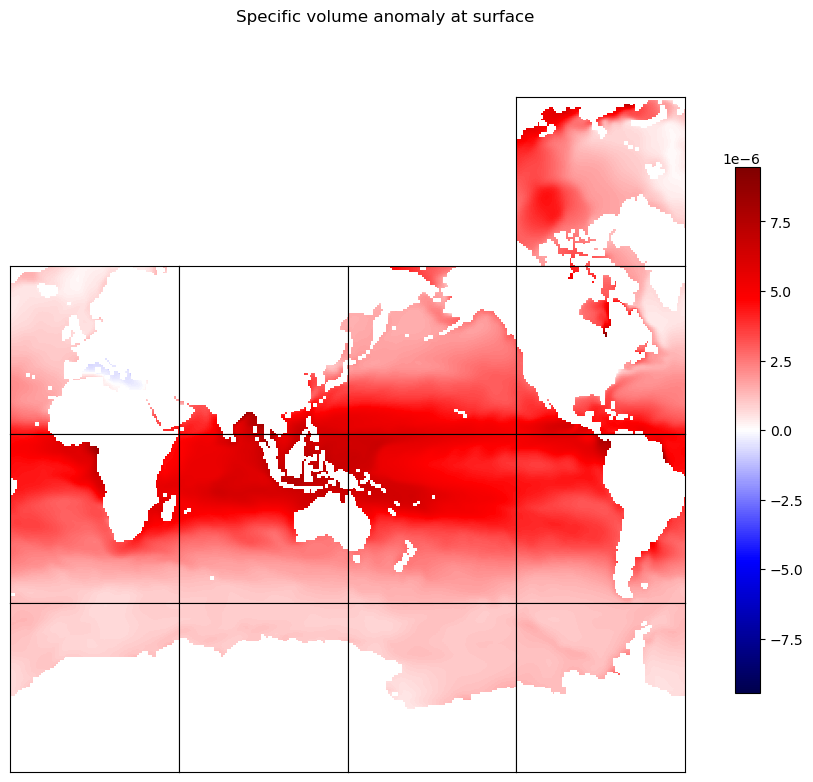

In [8]:
# # plot global tiles map of specific volume anomaly in topmost layer (k=0)

# k index (depth level) to plot
k_plot = 0

# 13 tiles map
curr_obj = ecco.plot_tiles(specvol_anom.isel(k=k_plot).squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=10,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10)
curr_fig = curr_obj[0]
curr_fig.suptitle('Specific volume anomaly at surface')

plt.show()

Notice that surface specific volume anomalies are largest in equatorial regions, particularly in the Indo-Pacific warm pool where surface waters are both very warm and relatively fresh (and therefore have relatively low density). Notice also that the specific volume anomaly is positive nearly everywhere, due to how the anomaly has been defined---based on water of temperature 0 C, at a salinity that is typical of ocean water but saltier than most water that cold.

### Steric height anomaly

Now we'll vertically integrate in pressure coordinates to obtain the steric height anomaly, relative to some reference pressure. In order to compute the integral in pressure coordinates, the pressure values are first computed at the top and bottom interfaces of each grid cell; then the integral is summed over grid cells above the defined reference pressure level.

In [9]:
# pressure reference level to compute steric height
# (in units of dbar, minus 10.1325 dbar atmospheric pressure)
p_r_sea_dbar = 2000.

p_r = (1.e4)*p_r_sea_dbar


# reference pressure at vertical grid cell boundaries
press_ref_k_u = (g*(-ds_grid.Zu))*rhoConst
press_ref_k_l = (g*(-ds_grid.Zl))*rhoConst

# mask for topography (set pressure below the bottom of the ocean to the ocean bottom value)
press_ref_bot = (g*ds_grid.Depth)*rhoConst
press_ref_k_u = press_ref_k_u.where(press_ref_k_u < press_ref_bot,press_ref_bot)
press_ref_k_l = press_ref_k_l.where(press_ref_k_l < press_ref_bot,press_ref_bot)

Now let's choose sea level pressure $p = p_{\rm{atm}}$ (i.e., sea pressure = 0 dbar) as the top limit of our integration, carry out the integration between these two levels, and plot the resulting map.

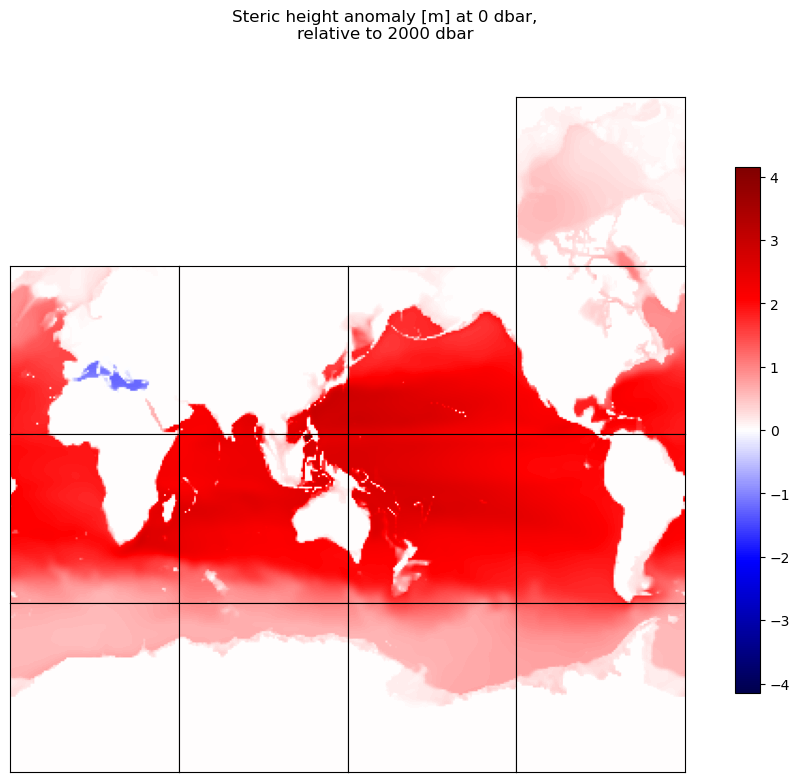

In [10]:
# # compute steric height anomaly at given pressure p_top_sea_dbar, relative to p_r_sea_dbar
p_top_sea_dbar = 0.

p_top = (1.e4)*p_top_sea_dbar

# dp for pressure integration,
# with dp outside pressure range [p_r,p_top] set to zero
dp_integrate = press_ref_k_l.where(press_ref_k_l > p_top,p_top).where(press_ref_k_l < p_r,p_r).values\
                    - press_ref_k_u.where(press_ref_k_u > p_top,p_top).where(press_ref_k_u < p_r,p_r).values

# multiply by hFacC (for partial bottom cells)
dp_integrate = ds_grid.hFacC*xr.DataArray(dp_integrate,dims=['k','tile','j','i'])

# scaling factor for z* coordinate system
rstarfac = 1 + (ds_SSH.ETAN/ds_grid.Depth)
dp_integrate = rstarfac*dp_integrate

# integrate in pressure coordinates to get steric height anomaly
steric_hgt_anom = (-(specvol_anom/g)*dp_integrate).sum("k")


# # plot global tiles map of steric height at sea level pressure, i.e. sea pressure = 0 dbar
# # relative to p_r_sea_dbar

# 13 tiles map
curr_obj = ecco.plot_tiles(steric_hgt_anom.squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=10,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10)
curr_fig = curr_obj[0]
curr_fig.suptitle('Steric height anomaly [m] at ' + str(int(p_top_sea_dbar)) + ' dbar,\n'\
                 + 'relative to ' + str(int(p_r_sea_dbar)) + ' dbar')

plt.show()

You can certainly make a few observations from the above map; notice the low steric height anomaly values in the high-salinity Mediterranean Sea for example. But there is a potential problem with the steric height anomaly integration, evident in the abrupt discontinuities across continental slopes (look closely at the areas near the Antarctic Peninsula or Argentina). When the bathymetry is shallower than the reference pressure level, this integration has assumed that the land areas are actually water parcels with the standard specific volume.

To avoid potentially misleading results, let's mask out all areas where the bathymetry is shallower than the $p_r$ pressure level. We'll plot this mask in gray along with a surface land mask in black, and for good measure we will rescale the steric height anomaly so that the global mean of the unmasked areas is removed.

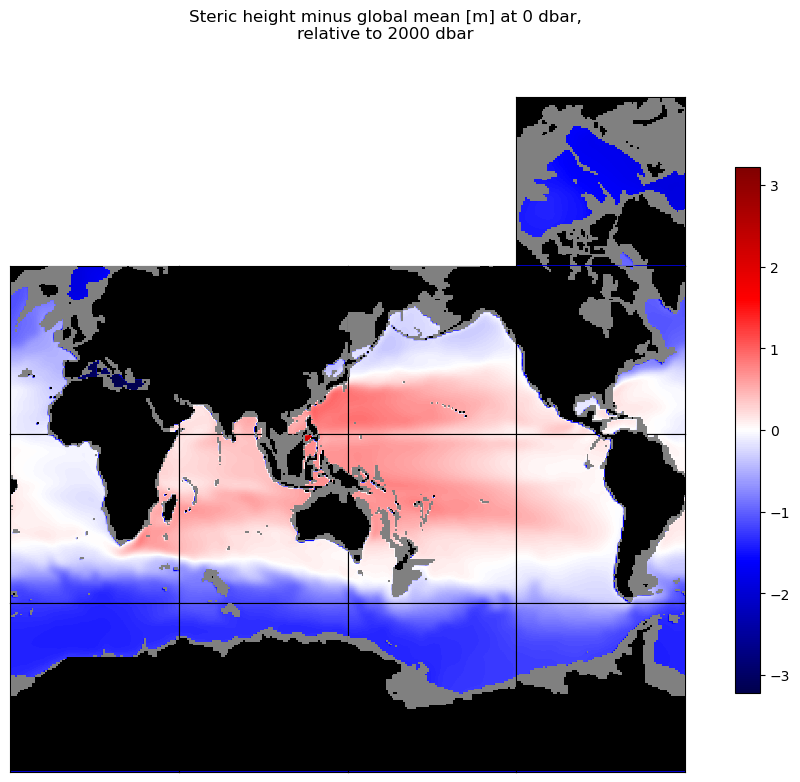

In [11]:
# load land mask (a boolean array) from grid parameters
land_mask = ~ds_grid.maskC

# surface land mask
land_mask_surf = land_mask.isel(k=0)

# mask out areas where sea pressure never reaches the reference pressure
too_shallow_mask = (press_ref_k_u.isel(k_u=-1) < p_r)

# steric height anomaly global mean, excluding masked areas
unmasked = (~land_mask_surf)*(~too_shallow_mask)
steric_hgt_globmean = np.sum(unmasked*ds_grid.rA*steric_hgt_anom)\
                        /np.sum(unmasked*ds_grid.rA)
steric_hgt_minus_globmean = steric_hgt_anom - steric_hgt_globmean


# function to plot a mask in ECCO tiles plots
def plot_mask_ecco_tiles(mask,color):
    """
    Plot mask in global ECCO tiles plot on current axes, 
    given 2-D mask (xarray DataArray) and color (a string, RGB tuple or 3-element NumPy array).
    """
    # loop through tiles to add mask
    tile_order = np.array([-1,-1,-1,6, \
                             2,5,7,10,  \
                             1,4,8,11, \
                             0,3,9,12])
    for idx,curr_ax in enumerate(curr_fig.get_axes()):
        if len(curr_ax.get_images()) > 0:
            # plot land mask
            array_plot = mask.isel(tile=tile_order[idx]).squeeze()
            if tile_order[idx] == 6:
                array_plot = np.rot90(array_plot,2)
            elif tile_order[idx] > 6:
                array_plot = np.rot90(array_plot)
            plot_mask(array_plot,ax=curr_ax,color=color)

# 13 tiles map
curr_obj = ecco.plot_tiles(steric_hgt_minus_globmean.squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=10,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10)
curr_fig = curr_obj[0]
plot_mask_ecco_tiles(too_shallow_mask,np.array([0.5,0.5,0.5]))    # plot too-shallow mask
plot_mask_ecco_tiles(land_mask_surf,np.zeros(3,))    # plot land mask

# add title
curr_fig.suptitle('Steric height minus global mean [m] at ' + str(int(p_top_sea_dbar)) + ' dbar,\n'\
                 + 'relative to ' + str(int(p_r_sea_dbar)) + ' dbar')

plt.show()

## Compare steric height with sea surface height

Of the 4 data variables in the SSH dataset, 3 are forms of sea surface height, just with different corrections applied. The ```SSH``` variable is the dynamic sea surface height anomaly. Importantly, it includes the correction for global mean steric effects, often called the Greatbatch correction; this is essential for tracking steric impacts on sea level over time. The inverted barometer (IB) correction is for the effect of atmospheric pressure on sea level; here we will use the ```SSH``` variable which has the IB correction, and best reflects changes in sea level due to ocean mass and density.

<Figure size 640x480 with 0 Axes>

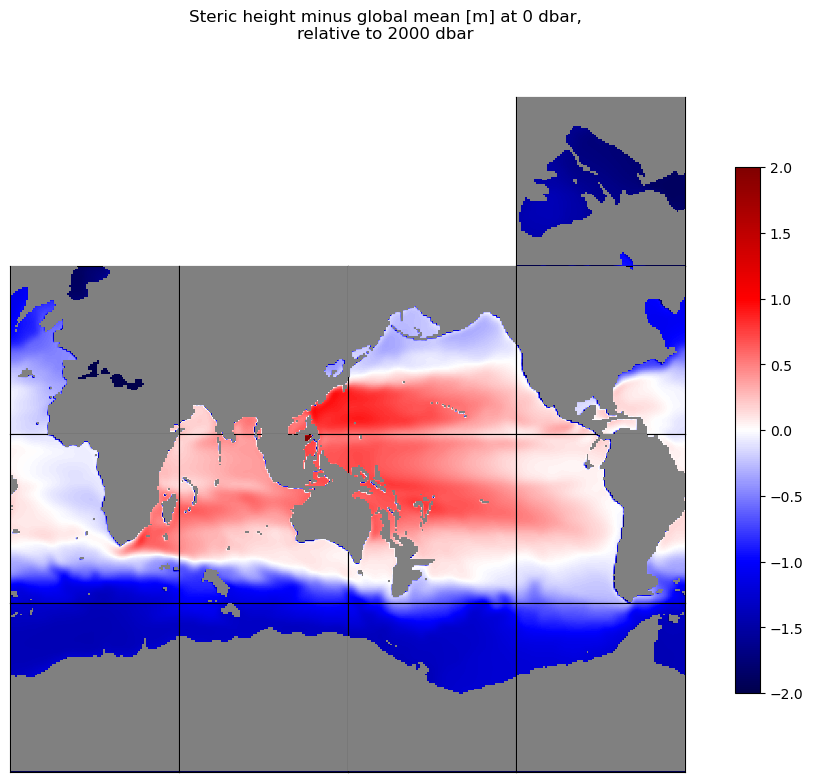

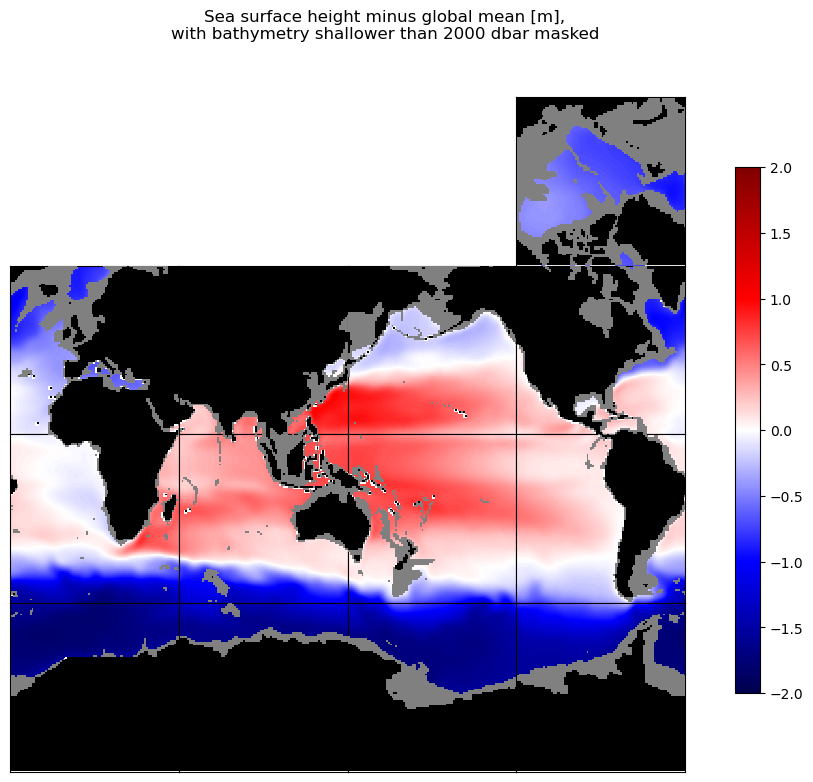

In [12]:
# remove global mean from SSH
SSH_globmean = np.sum((ds_grid.maskC.isel(k=0))*(ds_grid.rA)*ds_SSH.SSH)\
                    /np.sum((ds_grid.maskC.isel(k=0))*(ds_grid.rA))
SSH_minus_globmean = ds_SSH.SSH - SSH_globmean


# plot steric height and SSH minus respective global means

fig = plt.figure(constrained_layout=True)

subfigs = fig.subfigures(2,1)

curr_fig = subfigs[0]
# 13 tiles map
curr_obj = ecco.plot_tiles(steric_hgt_minus_globmean.squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=10,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10,\
                            cmin=-2.,cmax=2.)
curr_fig = curr_obj[0]
plot_mask_ecco_tiles(land_mask_surf,np.zeros(3,))    # plot land mask
plot_mask_ecco_tiles(too_shallow_mask,np.array([0.5,0.5,0.5]))    # plot too-shallow mask
curr_fig.suptitle('Steric height minus global mean [m] at ' + str(int(p_top_sea_dbar)) + ' dbar,\n'\
                 + 'relative to ' + str(int(p_r_sea_dbar)) + ' dbar')

curr_fig = subfigs[1]
# 13 tiles map
curr_obj = ecco.plot_tiles(SSH_minus_globmean.squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=10,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10,\
                            cmin=-2.,cmax=2.)
curr_fig = curr_obj[0]
plot_mask_ecco_tiles(too_shallow_mask,np.array([0.5,0.5,0.5]))    # plot too-shallow mask
plot_mask_ecco_tiles(land_mask_surf,np.zeros(3,))    # plot land mask
curr_fig.suptitle('Sea surface height minus global mean [m],\n' + \
                    'with bathymetry shallower than ' + str(int(p_r_sea_dbar)) + ' dbar masked')

plt.show()

Notice how similar these maps are, even though steric height is only one of the two primary components of sea level variation, and that the steric height map only includes the effect of density variations above 2000 dbar. A little more insight can be gained by taking the difference between the maps above to look at the non-steric height variation:

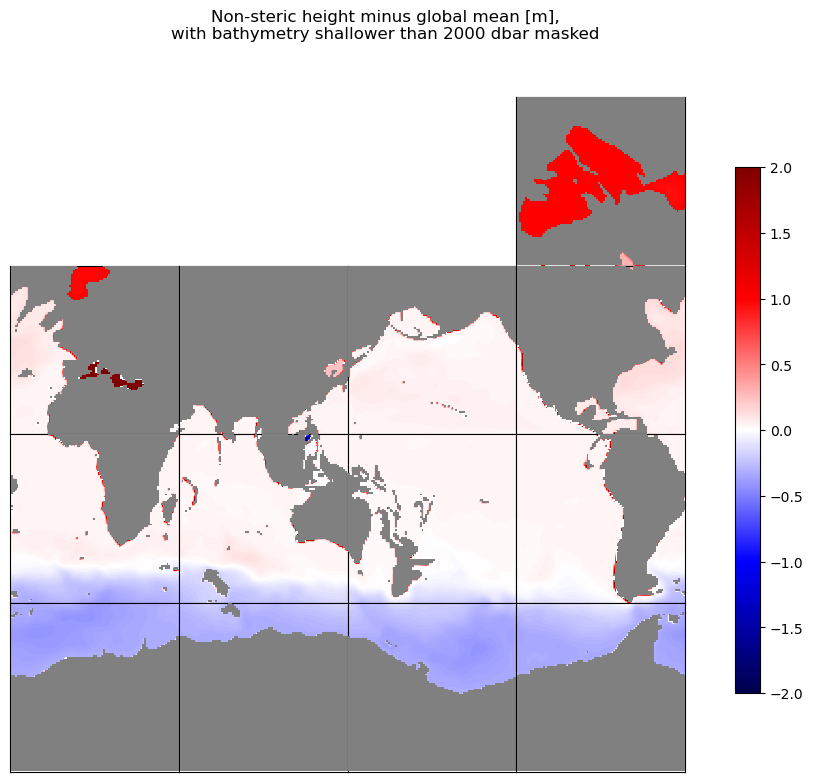

In [13]:
nonsteric_hgt_minus_globmean = SSH_minus_globmean - steric_hgt_minus_globmean

# 13 tiles map
curr_obj = ecco.plot_tiles(nonsteric_hgt_minus_globmean.squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=10,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10,\
                            cmin=-2.,cmax=2.)
curr_fig = curr_obj[0]
plot_mask_ecco_tiles(land_mask_surf,np.zeros(3,))    # plot land mask
plot_mask_ecco_tiles(too_shallow_mask,np.array([0.5,0.5,0.5]))    # plot too-shallow mask
curr_fig.suptitle('Non-steric height minus global mean [m],\n' + \
                  'with bathymetry shallower than ' + str(int(p_r_sea_dbar)) + ' dbar masked')

plt.show()

The map above implies that non-steric effects (or steric effects deeper than 2000 dbar) on the regional variation of sea level are relatively small, with a few notable exceptions. For example, south of the Antarctic Circumpolar Current (ACC), SSH is much lower than might be expected from 0-2000 dbar steric height anomalies, suggesting that either (a) deep ocean steric anomalies must explain the discrepancy, or (b) a gradient in vertically-integrated ocean mass (i.e. deep ocean pressure) is sustained across the ACC. Which explanation do you think it is, and how might we test that hypothesis?

## Thermosteric and halosteric contributions

### Definitions and methods

In the [Jackett and McDougall (1995)](https://doi.org/10.1175/1520-0426(1995)012%3C0381:MAOHPT%3E2.0.CO;2) equation of state of seawater, density is a function of three parameters: salinity, potential temperature, and pressure. The pressure contribution is almost entirely a function of depth and is negligible when considering horizontal variations in density. Since density variations are a major influence on the ocean circulation and sea level, as we have seen in this tutorial, oceanographers are interested in the distinct contributions that temperature and salinity make to density. These contributions are called the *thermosteric* and *halosteric* contributions respectively.

For small variations in temperature $T$ or salinity $S$, the relative contributions of each can be expressed as a linear approximation (e.g., Gill and Niiler 1973):

$$
{\Delta}\rho = \frac{\partial{\rho}}{\partial{S}}{\Delta}S + \frac{\partial{\rho}}{\partial{T}}{\Delta}T \equiv \rho\left({\beta}{\Delta}S - {\alpha}{\Delta}T\right)
$$

where we have defined a saline contraction coefficient $\beta \equiv (1/\rho)\partial{\rho}/\partial{S}$ and thermal expansion coefficient $\alpha \equiv -(1/\rho)\partial{\rho}/\partial{T}$ as the local derivatives of density with respect to salinity and temperature respectively. $\alpha$ and $\beta$ are unitless coefficients, and they can also be expressed in terms of specific volume $\alpha = (1/{V_{sp}})\partial{V_{sp}}/\partial{T}$ and $\beta = (1/{V_{sp}})\partial{V_{sp}}/\partial{S}$. These linear approximations are particularly useful in computing the effect of temperature and salinity on density gradients in a small area; on global scales the nonlinearity of TEOS may lead to distortions using this approximation.

To illustrate this, let's compute the thermosteric and halosteric contributions in two ways. In the first method, we will compute specific volume anomaly for each component using the linear approximations $\alpha$ and $\beta$ around the reference specific volume $V_r$ (corresponding to a potential temperature of ${\theta}_{r}$ = 0 deg C and salinity of $S_{r}$ = 35.16504 g/kg).

$$
{\rm Thermosteric}\,V_{sp}^{\prime} = {V_r}{\alpha_r}\left(\theta - \theta_{r}\right)
$$

$$
{\rm Halosteric}\,V_{sp}^{\prime} = -{V_r}{\beta_r}\left(S - S_{r}\right)
$$

where the subscript $_r$ indicates values computed at the reference $\theta_{r}$ and $S_{r}$.

In the second method, we will compute specific volume anomalies at each location while substituting in $S_{r} \rightarrow S$ when computing the thermosteric contribution and $\theta_{r} \rightarrow \theta$ when computing the halosteric contribution. In this way the specific volume anomaly is associated only with a difference in temperature or salinity respectively.

$$
{\rm Thermosteric}\,V_{sp}^{\prime} = V_{sp}\left\{S_{r},\theta_{r},p\right\} - V_{sp}\left\{S_{r},\theta_{r},p\right\}
$$

$$
{\rm Halosteric}\,V_{sp}^{\prime} = V_{sp}\left\{S,\theta_{r},p\right\} - V_{sp}\left\{S_{r},\theta_{r},p\right\}
$$

The difference between these two methods gives a sense of the impact of the nonlinearity of the equation of state on the steric height anomaly.

> Note: Defining **salinity** and **temperature**

> If you have used the newer [TEOS-10 thermodynamic equation of seawater](https://www.teos-10.org/), you may know that density is computed using *absolute* salinity and *conservative* temperature. What are these quantities? TEOS-10 takes into account the different composition of seawater solutes ("salts", but also other dissolved substances such as carbonates, silicates, nitrates) in different parts of the global oceans. These solutes have different impacts on electrical conductivity (the quantity typically observed as a proxy for salinity) vs. their impacts on seawater density. *Practical* salinity represents the salinity as observed using electrical conductivity (and assuming a "typical" seawater salt composition), while *absolute* salinity represents the contribution of seawater salts to density. Correspondingly, *potential* temperature is a temperature metric that remains adiabatic (unchanged absent heating/cooling) for a water parcel as its pressure changes. *Conservative* temperature is adiabatic to pressure changes **and** also is thermodynamically stable to the mixing of water parcels. JMD95 does not account for the composition of seawater solutes or the thermodynamic effects of mixing, so it is sufficient to use *potential* temperature and the model's salinity, which is equivalent to the TEOS-10 *absolute* salinity for most ocean modeling purposes.

### Method 1: Using expansion/contraction coefficients

Now we will compute the thermosteric and halosteric contributions to steric height anomaly using the thermal expansion coefficient $\alpha$ and the saline contraction coefficient $\beta$, as linearized around the reference $\theta_{r}$ and $S_{r}$. We can estimate these contributions by estimating the sensitivity of density to small changes in $\theta$ and $S$.

<Figure size 640x480 with 0 Axes>

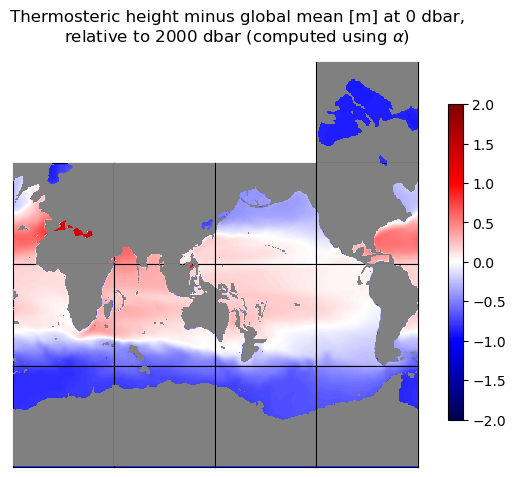

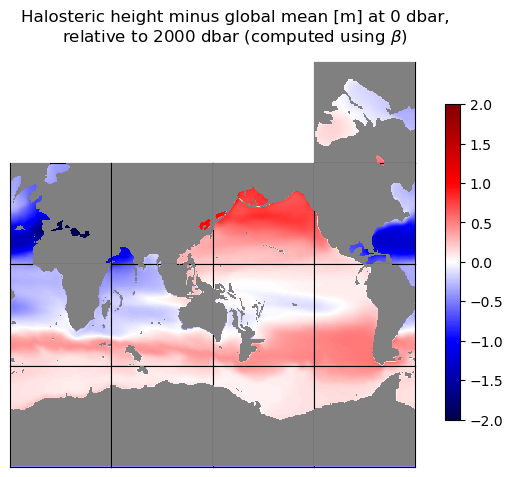

In [14]:
# thermal expansion coefficient alpha at theta_r, S_r
d_theta = 1.e-3
d_specvol = (1/densjmd95(S_r,theta_r + (0.5*d_theta),(1.e-4)*press_ref))\
            - (1/densjmd95(S_r,theta_r - (0.5*d_theta),(1.e-4)*press_ref))
# restore dimension to d_rho (it was removed in the densjmd95 function)
d_specvol = xr.DataArray(d_specvol,dims=['k'])

alpha = (d_specvol/specvol_standard)/d_theta

# saline contraction coefficient beta at T_Cr, S_Ar
d_S = 1.e-3
d_specvol = (1/densjmd95(S_r + (0.5*d_S),theta_r,(1.e-4)*press_ref))\
            - (1/densjmd95(S_r - (0.5*d_S),theta_r,(1.e-4)*press_ref))
# restore dimension to d_rho (it was removed in the densjmd95 function)
d_specvol = xr.DataArray(d_specvol,dims=['k'])

beta = -(d_specvol/specvol_standard)/d_S


# thermosteric and halosteric specific volume anomalies
specvol_thermo_anom_linear = specvol_standard*alpha*(ds_TS.THETA - theta_r)
specvol_halo_anom_linear = -specvol_standard*beta*(ds_TS.SALT - S_r)

# integrate vertically to obtain height anomalies
thermosteric_hgt_anom_linear = (-(specvol_thermo_anom_linear/g)*dp_integrate).sum("k")
halosteric_hgt_anom_linear = (-(specvol_halo_anom_linear/g)*dp_integrate).sum("k")


# contribution global means, excluding masked areas
thermosteric_hgt_linear_globmean = np.sum(unmasked*ds_grid.rA*thermosteric_hgt_anom_linear)\
                                            /np.sum(unmasked*ds_grid.rA)
halosteric_hgt_linear_globmean = np.sum(unmasked*ds_grid.rA*halosteric_hgt_anom_linear)\
                                            /np.sum(unmasked*ds_grid.rA)

# subtract global means
thermosteric_hgt_minus_globmean_linear = thermosteric_hgt_anom_linear \
                                        - thermosteric_hgt_linear_globmean
halosteric_hgt_minus_globmean_linear = halosteric_hgt_anom_linear \
                                        - halosteric_hgt_linear_globmean

# sum of two contributions
contribsum_hgt_minus_globmean_linear = thermosteric_hgt_minus_globmean_linear + \
                                    halosteric_hgt_minus_globmean_linear


# plot thermosteric and halosteric contributions (linear approximations),
# plus their sum and the full steric height anomaly

fig = plt.figure(constrained_layout=True)

subfigs = fig.subfigures(2,1)

curr_fig = subfigs[0]
# 13 tiles map
curr_obj = ecco.plot_tiles(thermosteric_hgt_minus_globmean_linear.squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=6,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10,\
                            cmin=-2.,cmax=2.)
curr_fig = curr_obj[0]
plot_mask_ecco_tiles(land_mask_surf,np.zeros(3,))    # plot land mask
plot_mask_ecco_tiles(too_shallow_mask,np.array([0.5,0.5,0.5]))    # plot too-shallow mask
curr_fig.suptitle('Thermosteric height minus global mean [m] at ' + str(int(p_top_sea_dbar)) + ' dbar,\n'\
                 + 'relative to ' + str(int(p_r_sea_dbar)) + ' dbar (computed using $\\alpha$)')

curr_fig = subfigs[1]
# 13 tiles map
curr_obj = ecco.plot_tiles(halosteric_hgt_minus_globmean_linear.squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=6,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10,\
                            cmin=-2.,cmax=2.)
curr_fig = curr_obj[0]
plot_mask_ecco_tiles(land_mask_surf,np.zeros(3,))    # plot land mask
plot_mask_ecco_tiles(too_shallow_mask,np.array([0.5,0.5,0.5]))    # plot too-shallow mask
curr_fig.suptitle('Halosteric height minus global mean [m] at ' + str(int(p_top_sea_dbar)) + ' dbar,\n'\
                 + 'relative to ' + str(int(p_r_sea_dbar)) + ' dbar (computed using $\\beta$)')

plt.show()

<Figure size 640x480 with 0 Axes>

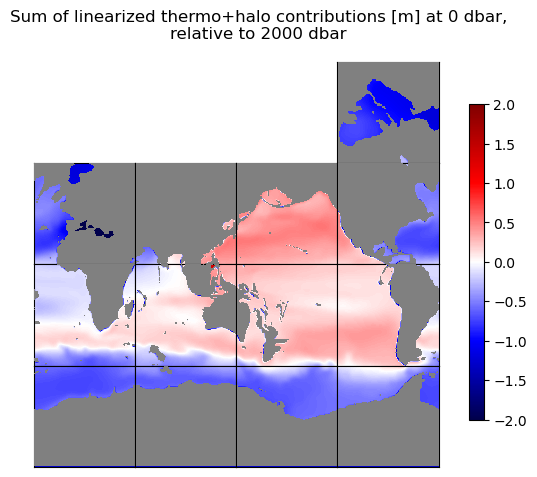

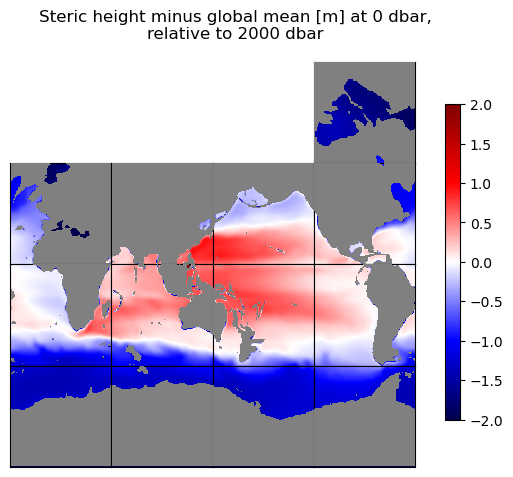

In [15]:
# plot sum of contributions vs. full steric height anomaly

fig = plt.figure(constrained_layout=True)

subfigs = fig.subfigures(2,1)

curr_fig = subfigs[0]
# 13 tiles map
curr_obj = ecco.plot_tiles(contribsum_hgt_minus_globmean_linear.squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=6,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10,\
                            cmin=-2.,cmax=2.)
curr_fig = curr_obj[0]
plot_mask_ecco_tiles(land_mask_surf,np.zeros(3,))    # plot land mask
plot_mask_ecco_tiles(too_shallow_mask,np.array([0.5,0.5,0.5]))    # plot too-shallow mask
curr_fig.suptitle('Sum of linearized thermo+halo contributions [m] at ' + str(int(p_top_sea_dbar)) + ' dbar,\n'\
                 + 'relative to ' + str(int(p_r_sea_dbar)) + ' dbar')

curr_fig = subfigs[1]
# 13 tiles map
curr_obj = ecco.plot_tiles(steric_hgt_minus_globmean.squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=6,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10,\
                            cmin=-2.,cmax=2.)
curr_fig = curr_obj[0]
plot_mask_ecco_tiles(land_mask_surf,np.zeros(3,))    # plot land mask
plot_mask_ecco_tiles(too_shallow_mask,np.array([0.5,0.5,0.5]))    # plot too-shallow mask
curr_fig.suptitle('Steric height minus global mean [m] at ' + str(int(p_top_sea_dbar)) + ' dbar,\n'\
                 + 'relative to ' + str(int(p_r_sea_dbar)) + ' dbar')

plt.show()

The first two maps show a thermosteric contribution that is largely latitude-dependent (no surprise), and a halosteric contribution that is very different in the Pacific (a fresher ocean) vs. the Atlantic and Indian oceans (more salty).

These patterns together help explain the full steric height variation in the last map above, though the sum of the two contributions obviously does not explain all of the full steric height variation.

### Method 2: Using specific volume differences

Now let's compute the thermosteric and halosteric contributions again, using the second method ($V_{sp}$ differences associated with temperature or salinity variations). This should account for at least some of the nonlinear aspects of TEOS.

<Figure size 640x480 with 0 Axes>

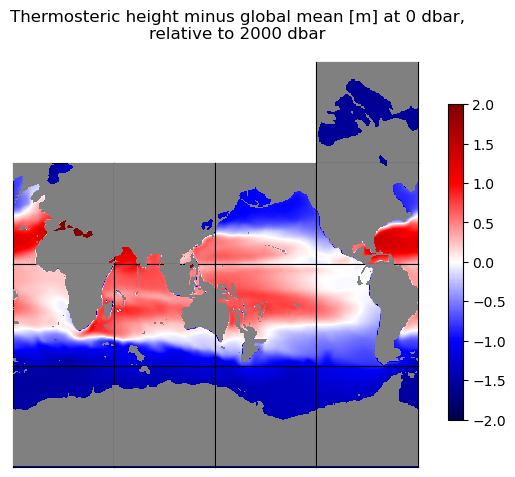

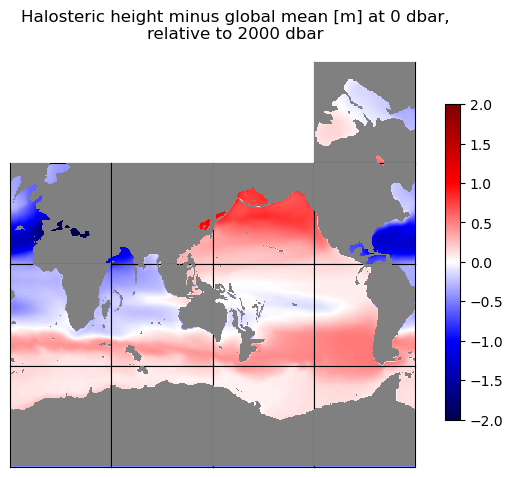

In [16]:
# compute specific volume anomalies due to temperature and salinity variations
press_ref_expanded = (press_ref*xr.ones_like(ds_TS.THETA)).transpose('time','k','tile','j','i')
specvol_thermo = 1/densjmd95(S_r,ds_TS.THETA,(1.e-4)*press_ref_expanded)
specvol_thermo = xr.DataArray(specvol_thermo,dims=['time','k','tile','j','i'])
specvol_thermo_anom = specvol_thermo - specvol_standard
specvol_halo = 1/densjmd95(ds_TS.SALT,theta_r,(1.e-4)*press_ref_expanded)
specvol_halo = xr.DataArray(specvol_halo,dims=['time','k','tile','j','i'])
specvol_halo_anom = specvol_halo - specvol_standard

# integrate vertically to obtain height anomalies
thermosteric_hgt_anom = (-(specvol_thermo_anom/g)*dp_integrate).sum("k")
halosteric_hgt_anom = (-(specvol_halo_anom/g)*dp_integrate).sum("k")


# contribution global means, excluding masked areas
thermosteric_hgt_globmean = np.sum(unmasked*ds_grid.rA*thermosteric_hgt_anom)\
                                            /np.sum(unmasked*ds_grid.rA)
halosteric_hgt_globmean = np.sum(unmasked*ds_grid.rA*halosteric_hgt_anom)\
                                            /np.sum(unmasked*ds_grid.rA)

# subtract global means
thermosteric_hgt_minus_globmean = thermosteric_hgt_anom \
                                        - thermosteric_hgt_globmean
halosteric_hgt_minus_globmean = halosteric_hgt_anom \
                                        - halosteric_hgt_globmean

# sum of two contributions
contribsum_hgt_minus_globmean = thermosteric_hgt_minus_globmean + \
                                    halosteric_hgt_minus_globmean


# plot thermosteric and halosteric contributions (linear approximations),
# plus their sum and the full steric height anomaly

fig = plt.figure(constrained_layout=True)

subfigs = fig.subfigures(2,1)

curr_fig = subfigs[0]
# 13 tiles map
curr_obj = ecco.plot_tiles(thermosteric_hgt_minus_globmean.squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=6,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10,\
                            cmin=-2.,cmax=2.)
curr_fig = curr_obj[0]
plot_mask_ecco_tiles(land_mask_surf,np.zeros(3,))    # plot land mask
plot_mask_ecco_tiles(too_shallow_mask,np.array([0.5,0.5,0.5]))    # plot too-shallow mask
curr_fig.suptitle('Thermosteric height minus global mean [m] at ' + str(int(p_top_sea_dbar)) + ' dbar,\n'\
                 + 'relative to ' + str(int(p_r_sea_dbar)) + ' dbar')

curr_fig = subfigs[1]
# 13 tiles map
curr_obj = ecco.plot_tiles(halosteric_hgt_minus_globmean.squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=6,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10,\
                            cmin=-2.,cmax=2.)
curr_fig = curr_obj[0]
plot_mask_ecco_tiles(land_mask_surf,np.zeros(3,))    # plot land mask
plot_mask_ecco_tiles(too_shallow_mask,np.array([0.5,0.5,0.5]))    # plot too-shallow mask
curr_fig.suptitle('Halosteric height minus global mean [m] at ' + str(int(p_top_sea_dbar)) + ' dbar,\n'\
                 + 'relative to ' + str(int(p_r_sea_dbar)) + ' dbar')

plt.show()

And now let's compare the sum of the contributions with the full steric height anomaly again.

<Figure size 640x480 with 0 Axes>

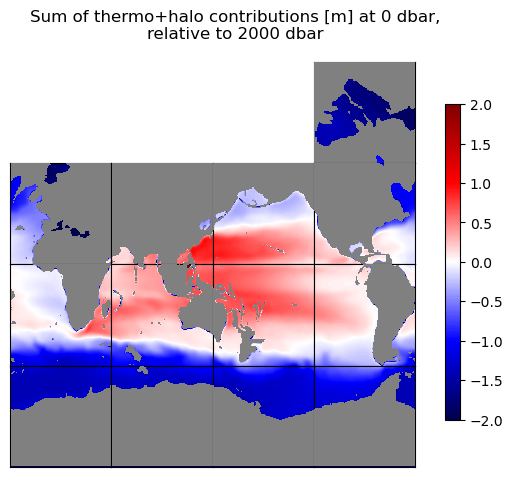

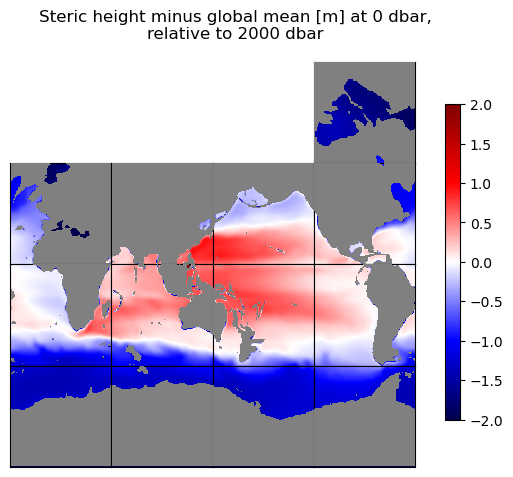

In [17]:
# plot sum of contributions vs. full steric height anomaly

fig = plt.figure(constrained_layout=True)

subfigs = fig.subfigures(2,1)

curr_fig = subfigs[0]
# 13 tiles map
curr_obj = ecco.plot_tiles(contribsum_hgt_minus_globmean.squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=6,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10,\
                            cmin=-2.,cmax=2.)
curr_fig = curr_obj[0]
plot_mask_ecco_tiles(land_mask_surf,np.zeros(3,))    # plot land mask
plot_mask_ecco_tiles(too_shallow_mask,np.array([0.5,0.5,0.5]))    # plot too-shallow mask
curr_fig.suptitle('Sum of thermo+halo contributions [m] at ' + str(int(p_top_sea_dbar)) + ' dbar,\n'\
                 + 'relative to ' + str(int(p_r_sea_dbar)) + ' dbar')

curr_fig = subfigs[1]
# 13 tiles map
curr_obj = ecco.plot_tiles(steric_hgt_minus_globmean.squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=6,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10,\
                            cmin=-2.,cmax=2.)
curr_fig = curr_obj[0]
plot_mask_ecco_tiles(land_mask_surf,np.zeros(3,))    # plot land mask
plot_mask_ecco_tiles(too_shallow_mask,np.array([0.5,0.5,0.5]))    # plot too-shallow mask
curr_fig.suptitle('Steric height minus global mean [m] at ' + str(int(p_top_sea_dbar)) + ' dbar,\n'\
                 + 'relative to ' + str(int(p_r_sea_dbar)) + ' dbar')

plt.show()

It looks like this time we did a much better job of accounting for the full steric height variation!

## Exercises

1. Using the `lon_depth_along_lat` function defined in the thermal wind tutorial (and already imported here as part of the `ecco_py_tutorials` module), plot steric height anomalies and the thermosteric and halosteric contributions along a line of latitude around the globe. Since these anomalies have been vertically integrated, you may need to re-add the `k` dimension to the DataArrays before using this function; you can use [expand_dims](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.expand_dims.html):

      {array_name} = {array_name}.expand_dims(dim={"k":ds_grid.Z.values[0]},axis=-4)

      How do the relative contributions of temperature and salinity look different when following a line of latitude? You can also see how the reference pressure impacts the result by re-running this notebook with a different `p_r_sea_dbar` as input.

1. Look at the change in steric height over time. Download the monthly density/pressure, SSH, and temperature/salinity files for each month in the year 1992, open the files using open_mfdataset, and average them in 1992 (the first year in the ECCOv4 output). Do the same for the year 2017 (the last year in the ECCOv4 output). Create maps similar to the ones in this tutorial, but for the (2017 mean) - (1992 mean). How did the steric, thermosteric, and halosteric contributions change over this 25-year period, and how do they compare to the change in dynamic SSH?

1. For this exercise you'll download the density/pressure, SSH, and temperature/salinity files for the entire period 1992 through 2017. Plot time series of the global mean steric, thermosteric, and halosteric height alongside dynamic SSH. For extra credit, remove the seasonal cycle (by subtracting January means, February means, etc.) to make the longer time scale changes clearer.

## References

Gill, A.E. (1982). ***Atmosphere-Ocean Dynamics***. Academic Press, Elsevier.

Gill, A.E. & P.P. Niiler (1973). The theory of the seasonal variability in the ocean. *Deep Sea Research and Oceanographic Abstracts*, **20(2)**, 141-177. https://doi.org/10.1016/0011-7471(73)90049-1.

Vallis, G.K. (2006). ***Atmospheric and Oceanic Fluid Dynamics***. Cambridge University Press.